<a href="https://colab.research.google.com/github/Aminah-creat/BUSINESS_INTELLIGENCE_ASSIGNMENT1_UWIMANA_Amina_223009215/blob/main/BI_Assignment_two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving BI_Retail_Case_Study.xlsx to BI_Retail_Case_Study.xlsx


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FILE = "BI_Retail_Case_Study.xlsx"
import os
if not os.path.exists(FILE):
    try:
        from google.colab import files
        up = files.upload()          # choose BI_Retail_Case_Study.xlsx
        FILE = list(up.keys())[0]
    except Exception as e:
        print("Upload the xlsx manually or set FILE to its path.", e)
print("Using file:", FILE)

Using file: BI_Retail_Case_Study.xlsx


In [15]:
sales = pd.read_excel(FILE, "SalesRaw")
prod  = pd.read_excel(FILE, "DimProduct")
cust  = pd.read_excel(FILE, "DimCustomer")
store = pd.read_excel(FILE, "DimStore")
emp   = pd.read_excel(FILE, "DimEmployee")
date  = pd.read_excel(FILE, "DimDate")
tgt   = pd.read_excel(FILE, "Targets")
print({s: df.shape for s, df in zip(
    ["SalesRaw","DimProduct","DimCustomer","DimStore","DimEmployee","DimDate","Targets"],
    [sales,prod,cust,store,emp,date,tgt])})
sales.head()

{'SalesRaw': (25035, 14), 'DimProduct': (60, 5), 'DimCustomer': (5000, 6), 'DimStore': (8, 5), 'DimEmployee': (40, 4), 'DimDate': (365, 8), 'Targets': (96, 3)}


,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales
0,TX100000,2025-06-29,3,2016,10538,10,2,"2,660.00",0.10,Store,Mobile Money,5320,532.00,"4,788.00"
1,TX100001,2025-12-31,6,2028,10107,26,6,"25,204.00",0.05,Store,Mobile Money,151224,"7,561.20","143,662.80"
2,TX100002,2025-08-30,2,2036,13854,51,1,"8,468.00",0.05,Online,Bank Transfer,8468,423.40,"8,044.60"
3,TX100003,2025-06-09,5,2033,11230,3,3,"1,819.00",0.00,Store,Bank Transfer,5457,0.00,"5,457.00"
4,TX100004,2025-01-10,3,2019,10395,42,1,"2,310.00",0.02,Store,Card,2310,46.20,"2,263.80"


In [16]:
print("Raw SalesChannel:", sales["SalesChannel"].unique())
print("Raw PaymentMethod:", sales["PaymentMethod"].unique())
print("Missing DiscountPct rows:", sales["DiscountPct"].isna().sum())

Raw SalesChannel: ['Store' 'Online' 'Corporate' ' Store ' ' Online ' ' Corporate ']
Raw PaymentMethod: ['Mobile Money' 'Bank Transfer' 'Card' 'Cash' 'cash' 'mobile money' 'card'
 'bank transfer']
Missing DiscountPct rows: 60


In [17]:
sales["TransactionDate"] = pd.to_datetime(sales["TransactionDate"])
sales["SalesChannel"]  = sales["SalesChannel"].str.strip().str.title()
sales["PaymentMethod"] = sales["PaymentMethod"].str.strip().str.title()
tgt["Month"] = pd.to_datetime(tgt["Month"])

df = (sales
      .merge(prod[["ProductID","ProductName","Category","UnitCost"]], on="ProductID", how="left")
      .merge(store[["StoreID","StoreName","StoreType","Province"]], on="StoreID", how="left")
      .merge(cust[["CustomerID","CustomerType","District","Age","Gender"]], on="CustomerID", how="left"))

df["COGS"]        = df["Quantity"] * df["UnitCost"]
df["GrossProfit"] = df["NetSales"] - df["COGS"]
df["Margin"]      = df["GrossProfit"] / df["NetSales"]
df["YearMonth"]   = df["TransactionDate"].dt.to_period("M").dt.to_timestamp()

print("Clean SalesChannel:", df["SalesChannel"].unique())
print(f"Rows: {len(df):,} | Total Net Sales: {df.NetSales.sum():,.0f} | "
      f"Total Gross Profit: {df.GrossProfit.sum():,.0f} | "
      f"Overall Margin: {df.GrossProfit.sum()/df.NetSales.sum():.1%}")
df.head(3)

Clean SalesChannel: ['Store' 'Online' 'Corporate']
Rows: 25,035 | Total Net Sales: 1,234,368,023 | Total Gross Profit: 329,491,323 | Overall Margin: 26.7%


,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,...,StoreType,Province,CustomerType,District,Age,Gender,COGS,GrossProfit,Margin,YearMonth
0,TX100000,2025-06-29,3,2016,10538,10,2,"2,660.00",0.10,Store,...,Urban,Kigali,Individual,Nyanza,40,Female,3800,988.00,0.21,2025-06-01
1,TX100001,2025-12-31,6,2028,10107,26,6,"25,204.00",0.05,Store,...,Secondary City,Southern,Individual,Nyamagabe,45,Male,81000,"62,662.80",0.44,2025-12-01
2,TX100002,2025-08-30,2,2036,13854,51,1,"8,468.00",0.05,Online,...,Urban,Kigali,SME,Nyarugenge,35,Female,6100,"1,944.60",0.24,2025-08-01


In [18]:
store_kpi = (df.groupby("StoreName")
    .agg(NetSales=("NetSales","sum"),
         Transactions=("TransactionID","count"),
         QuantitySold=("Quantity","sum"),
         GrossProfit=("GrossProfit","sum"))
    .reset_index())
store_kpi["ProfitMargin%"] = store_kpi.GrossProfit / store_kpi.NetSales * 100
store_kpi["AvgTxnValue"]   = store_kpi.NetSales / store_kpi.Transactions

store_tgt = (tgt.groupby("StoreID").SalesTarget.sum()
             .reset_index().merge(store[["StoreID","StoreName"]], on="StoreID"))
store_kpi = store_kpi.merge(store_tgt[["StoreName","SalesTarget"]], on="StoreName", how="left")
store_kpi["TargetAchievement%"] = store_kpi.NetSales / store_kpi.SalesTarget * 100

store_kpi = store_kpi.sort_values("NetSales", ascending=False).reset_index(drop=True)
store_kpi.round(1)

,StoreName,NetSales,Transactions,QuantitySold,GrossProfit,ProfitMargin%,AvgTxnValue,SalesTarget,TargetAchievement%
0,Kigali City Centre,"244,468,330.30",4926,12800,"66,405,280.30",27.20,"49,628.20",223409400,109.40
1,Kimironko,"185,077,376.00",3983,10058,"49,545,876.00",26.80,"46,466.80",231208792,80.00
2,Kicukiro Mall,"159,184,431.40",3234,8418,"42,831,581.40",26.90,"49,222.10",303988639,52.40
3,Musanze Central,"138,977,336.10",2742,7174,"37,267,336.10",26.80,"50,684.70",289681342,48.00
4,Nyagatare Plaza,"132,517,104.80",2626,6856,"35,185,954.80",26.60,"50,463.50",267339124,49.60
5,Rubavu Centre,"129,660,749.20",2423,6293,"32,994,199.20",25.40,"53,512.50",255687843,50.70
6,Muhanga Hub,"124,232,355.20",2554,6639,"33,454,905.20",26.90,"48,642.30",294252929,42.20
7,Huye Market,"120,250,339.90",2547,6668,"31,806,189.90",26.40,"47,212.50",168349961,71.40


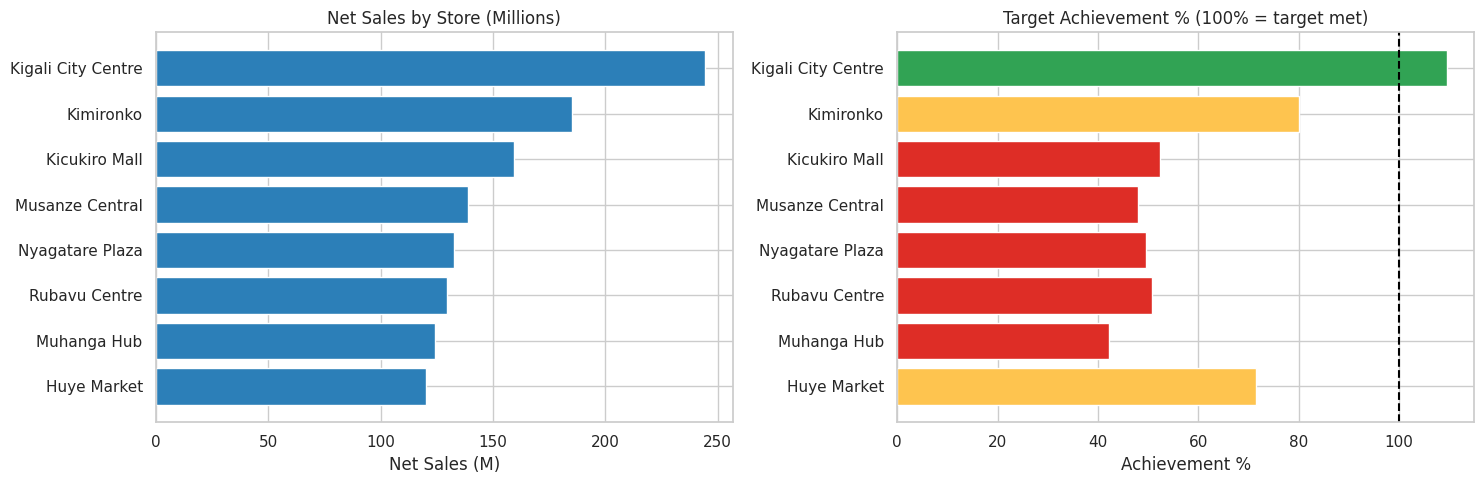

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sk = store_kpi.sort_values("NetSales")
ax[0].barh(sk.StoreName, sk.NetSales/1e6, color="#2c7fb8")
ax[0].set_title("Net Sales by Store (Millions)"); ax[0].set_xlabel("Net Sales (M)")
colors = ["#31a354" if v>=100 else ("#fec44f" if v>=70 else "#de2d26") for v in sk["TargetAchievement%"]]
ax[1].barh(sk.StoreName, sk["TargetAchievement%"], color=colors)
ax[1].axvline(100, ls="--", c="black"); ax[1].set_title("Target Achievement % (100% = target met)")
ax[1].set_xlabel("Achievement %")
plt.tight_layout(); plt.show()

Question two


In [20]:
monthly = (df.groupby(["StoreID","YearMonth"]).NetSales.sum().reset_index()
           .merge(tgt, left_on=["StoreID","YearMonth"], right_on=["StoreID","Month"], how="left"))
monthly["Achievement%"] = monthly.NetSales / monthly.SalesTarget * 100

comp = monthly.groupby("YearMonth").agg(NetSales=("NetSales","sum"), Target=("SalesTarget","sum"))
comp["Achievement%"] = comp.NetSales / comp.Target * 100
comp.round(1)

,NetSales,Target,Achievement%
YearMonth,,,
2025-01-01,"103,725,348.20",158999220,65.20
2025-02-01,"93,272,333.00",160907211,58.00
2025-03-01,"103,131,572.00",162815202,63.30
2025-04-01,"105,782,386.30",164723193,64.20
2025-05-01,"92,698,443.20",166631183,55.60
2025-06-01,"107,702,440.50",168539174,63.90
2025-07-01,"102,155,408.00",170447165,59.90
2025-08-01,"101,761,858.90",172355155,59.00
2025-09-01,"106,788,465.70",174263145,61.30


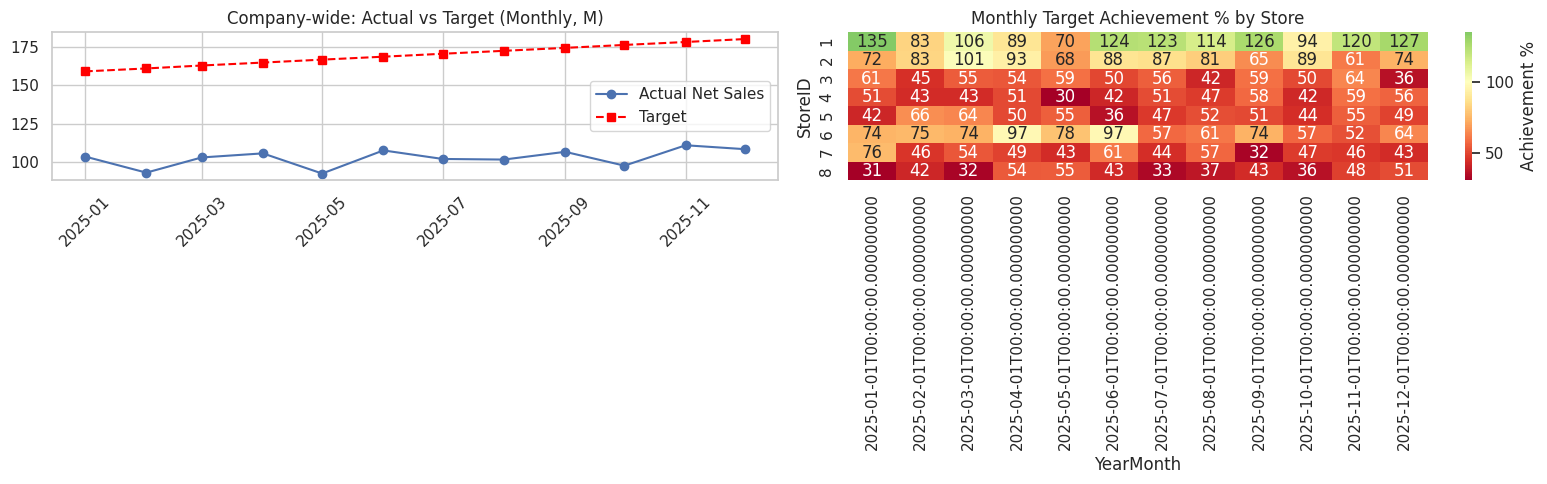

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))
ax[0].plot(comp.index, comp.NetSales/1e6, "-o", label="Actual Net Sales")
ax[0].plot(comp.index, comp.Target/1e6, "--s", color="red", label="Target")
ax[0].set_title("Company-wide: Actual vs Target (Monthly, M)"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=45)

pivot = monthly.pivot(index="YearMonth", columns="StoreID", values="Achievement%")
sns.heatmap(pivot.T, annot=True, fmt=".0f", cmap="RdYlGn", center=100, ax=ax[1],
            cbar_kws={"label":"Achievement %"})
ax[1].set_title("Monthly Target Achievement % by Store")
plt.tight_layout(); plt.show()

Question 3

In [22]:
cust_type = (df.groupby("CustomerType")
    .agg(TotalSales=("NetSales","sum"),
         Transactions=("TransactionID","count"),
         QuantityPurchased=("Quantity","sum"),
         GrossProfit=("GrossProfit","sum"))
    .reset_index())
cust_type["AvgTxnValue"]   = cust_type.TotalSales / cust_type.Transactions
cust_type["ProfitMargin%"] = cust_type.GrossProfit / cust_type.TotalSales * 100
cust_type["Sales%"]        = cust_type.TotalSales / cust_type.TotalSales.sum() * 100
cust_type["Profit%"]       = cust_type.GrossProfit / cust_type.GrossProfit.sum() * 100
cust_type.sort_values("TotalSales", ascending=False).round(1)

,CustomerType,TotalSales,Transactions,QuantityPurchased,GrossProfit,AvgTxnValue,ProfitMargin%,Sales%,Profit%
0,Individual,"892,640,264.90",18174,47176,"238,105,914.90","49,116.30",26.70,72.30,72.30
2,SME,"269,436,995.90",5588,14380,"72,924,045.90","48,217.10",27.10,21.80,22.10
1,Institution,"72,290,762.30",1273,3350,"18,461,362.30","56,787.70",25.50,5.90,5.60


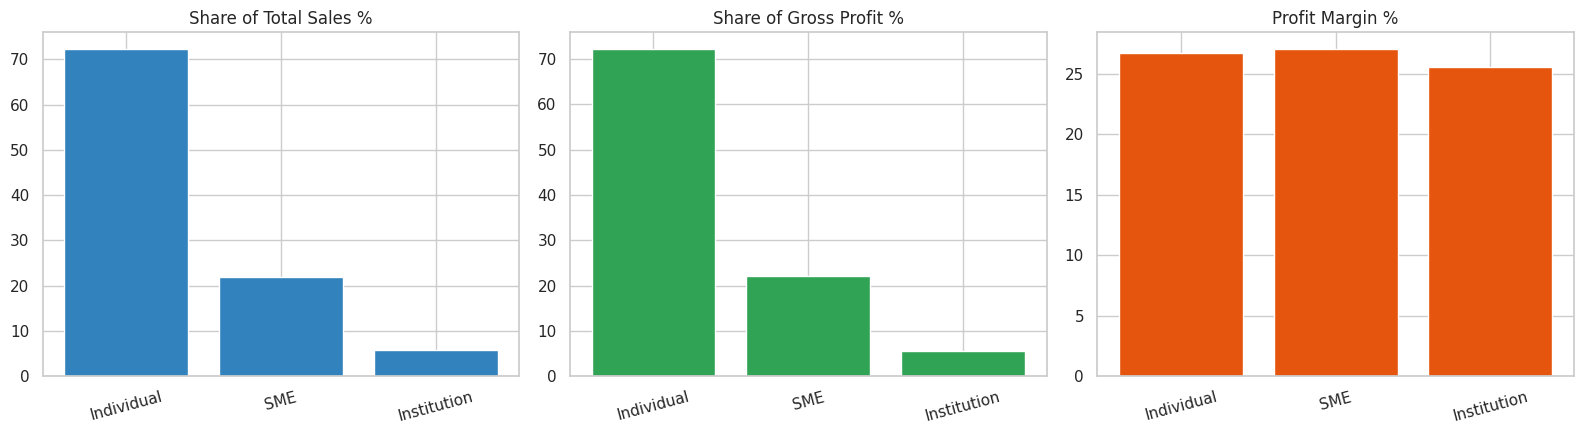

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
c = cust_type.sort_values("TotalSales", ascending=False)
ax[0].bar(c.CustomerType, c["Sales%"], color="#3182bd"); ax[0].set_title("Share of Total Sales %")
ax[1].bar(c.CustomerType, c["Profit%"], color="#31a354"); ax[1].set_title("Share of Gross Profit %")
ax[2].bar(c.CustomerType, c["ProfitMargin%"], color="#e6550d"); ax[2].set_title("Profit Margin %")
for a in ax: a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

Question 4

In [24]:
snapshot = df.TransactionDate.max() + pd.Timedelta(days=1)
rfm = (df.groupby("CustomerID").agg(
        Recency=("TransactionDate", lambda x: (snapshot - x.max()).days),
        Frequency=("TransactionID", "count"),
        Monetary=("NetSales", "sum")).reset_index())

rfm["R"] = pd.qcut(rfm.Recency, 4, labels=[4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm.Frequency.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M"] = pd.qcut(rfm.Monetary, 4, labels=[1,2,3,4]).astype(int)
rfm["RFM_Score"] = rfm.R + rfm.F + rfm.M

def segment(s):
    if s >= 10: return "Champions / Loyal"
    if s >= 7:  return "Potential Loyalist"
    if s >= 5:  return "Needs Attention"
    return "At Risk / Lost"
rfm["Segment"] = rfm.RFM_Score.apply(segment)

seg = (rfm.groupby("Segment").agg(Customers=("CustomerID","count"),
        AvgRecency=("Recency","mean"), AvgFrequency=("Frequency","mean"),
        AvgMonetary=("Monetary","mean"), TotalMonetary=("Monetary","sum")).reset_index())
seg["Customer%"] = seg.Customers / seg.Customers.sum() * 100
seg["Revenue%"]  = seg.TotalMonetary / seg.TotalMonetary.sum() * 100
seg.sort_values("Revenue%", ascending=False).round(1)

,Segment,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalMonetary,Customer%,Revenue%
1,Champions / Loyal,1266,26.40,7.30,"485,561.90","614,721,306.70",25.40,49.80
3,Potential Loyalist,1933,57.30,5.30,"243,948.30","471,551,975.60",38.90,38.20
2,Needs Attention,1013,87.10,3.70,"110,635.50","112,073,774.00",20.40,9.10
0,At Risk / Lost,763,164.00,2.50,"47,209.70","36,020,966.70",15.30,2.90


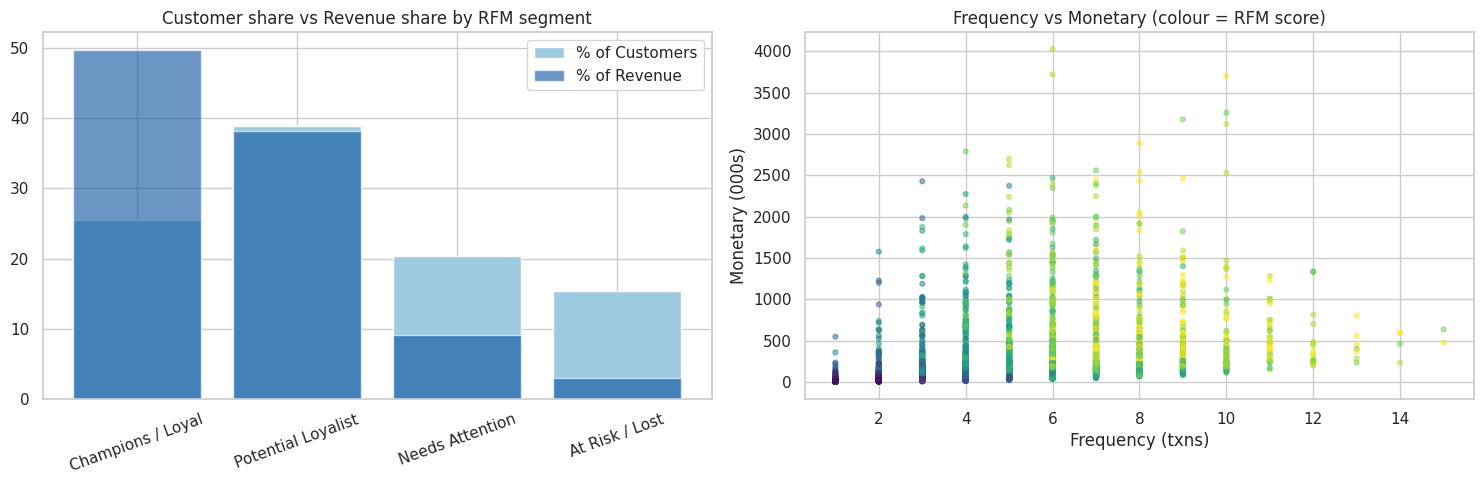

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sg = seg.sort_values("Revenue%", ascending=False)
ax[0].bar(sg.Segment, sg["Customer%"], color="#9ecae1", label="% of Customers")
ax[0].bar(sg.Segment, sg["Revenue%"], color="#08519c", alpha=0.6, label="% of Revenue")
ax[0].set_title("Customer share vs Revenue share by RFM segment"); ax[0].legend()
ax[0].tick_params(axis="x", rotation=20)
ax[1].scatter(rfm.Frequency, rfm.Monetary/1e3, c=rfm.RFM_Score, cmap="viridis", s=12, alpha=0.5)
ax[1].set_xlabel("Frequency (txns)"); ax[1].set_ylabel("Monetary (000s)")
ax[1].set_title("Frequency vs Monetary (colour = RFM score)")
plt.tight_layout(); plt.show()

Question 5

In [26]:
cat = (df.groupby("Category")
    .agg(NetSales=("NetSales","sum"), QuantitySold=("Quantity","sum"),
         GrossProfit=("GrossProfit","sum"), AvgDiscount=("DiscountPct","mean"))
    .reset_index())
cat["ProfitMargin%"] = cat.GrossProfit / cat.NetSales * 100
cat["AvgDiscount%"]  = cat.AvgDiscount * 100
cat["Sales%"]        = cat.NetSales / cat.NetSales.sum() * 100
cat["Profit%"]       = cat.GrossProfit / cat.GrossProfit.sum() * 100
cat = cat.sort_values("NetSales", ascending=False).reset_index(drop=True)
cat.round(1)

,Category,NetSales,QuantitySold,GrossProfit,AvgDiscount,ProfitMargin%,AvgDiscount%,Sales%,Profit%
0,Electronics,"648,827,368.50",10762,"138,824,268.50",0.00,21.40,4.10,52.60,42.10
1,Home & Kitchen,"251,552,603.00",11075,"85,044,903.00",0.00,33.80,4.20,20.40,25.80
2,Agriculture,"112,977,816.50",10401,"35,516,116.50",0.00,31.40,4.20,9.20,10.80
3,Personal Care,"99,739,597.90",11047,"32,576,597.90",0.00,32.70,4.20,8.10,9.90
4,Office & Stationery,"91,296,939.80",10858,"29,794,439.80",0.00,32.60,4.20,7.40,9.00
5,Food & Beverage,"29,973,697.30",10763,"7,734,997.30",0.00,25.80,4.20,2.40,2.30


Top 10 products by Net Sales:
                          NetSales   GrossProfit  Margin%
ProductName                                              
Smartphone Midrange 329,773,039.20 57,688,039.20    17.50
Smartphone Entry    185,777,298.00 35,267,298.00    19.00
Blender              43,103,458.90 12,722,458.90    29.50
Dinner Set           38,043,156.00 12,168,156.00    32.00
Bedsheet Set         36,833,056.00 11,906,056.00    32.30
Printer Ink          34,979,962.60  9,532,462.60    27.30
Knapsack Sprayer     33,246,166.90  9,586,166.90    28.80
Perfume              29,677,705.50  9,401,705.50    31.70
Electric Kettle      29,632,282.20  9,976,282.20    33.70
Bluetooth Speaker    28,584,056.90  9,011,056.90    31.50


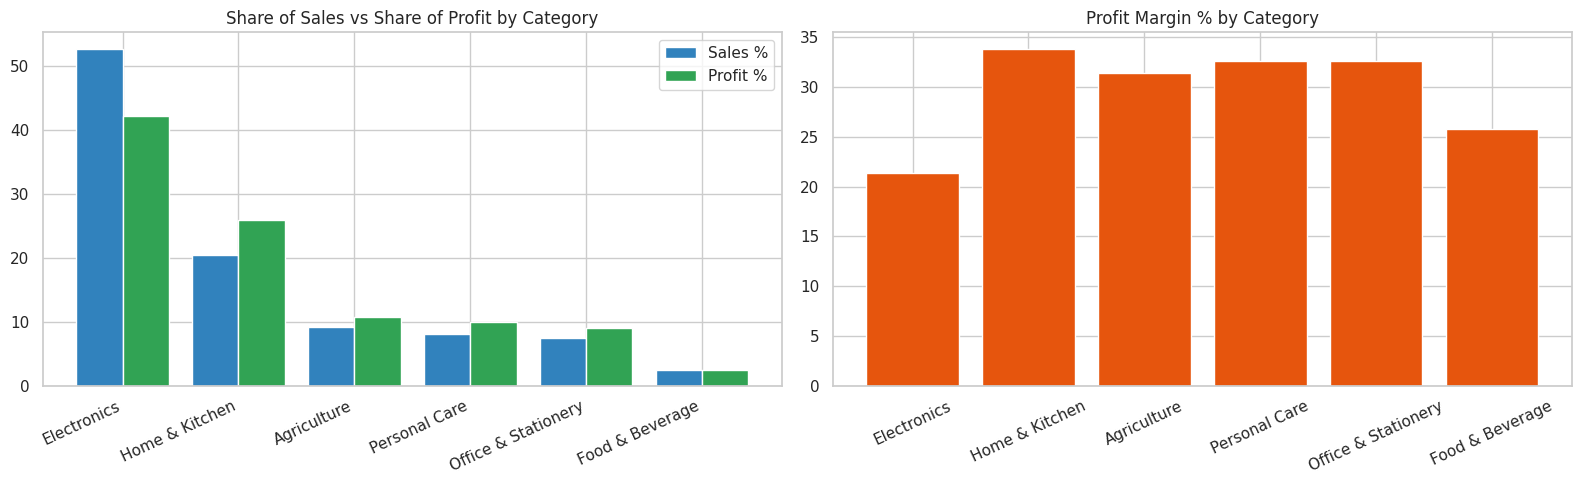

In [27]:
top_prod = df.groupby("ProductName").agg(NetSales=("NetSales","sum"), GrossProfit=("GrossProfit","sum"))
top_prod["Margin%"] = top_prod.GrossProfit/top_prod.NetSales*100
print("Top 10 products by Net Sales:")
print(top_prod.sort_values("NetSales", ascending=False).head(10).round(1))

fig, ax = plt.subplots(1, 2, figsize=(16,5))
x = np.arange(len(cat)); w = 0.4
ax[0].bar(x-w/2, cat["Sales%"], w, label="Sales %", color="#3182bd")
ax[0].bar(x+w/2, cat["Profit%"], w, label="Profit %", color="#31a354")
ax[0].set_xticks(x); ax[0].set_xticklabels(cat.Category, rotation=25, ha="right")
ax[0].set_title("Share of Sales vs Share of Profit by Category"); ax[0].legend()
ax[1].bar(cat.Category, cat["ProfitMargin%"], color="#e6550d")
ax[1].set_title("Profit Margin % by Category"); ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

Question 6

In [28]:
d = df.dropna(subset=["DiscountPct"]).copy()

pear_r, pear_p = stats.pearsonr(d.DiscountPct, d.Margin)
spear_r, spear_p = stats.spearmanr(d.DiscountPct, d.Margin)
print(f"Pearson  r = {pear_r:.3f} (p = {pear_p:.2e})")
print(f"Spearman r = {spear_r:.3f} (p = {spear_p:.2e})")

band = (d.groupby("DiscountPct").agg(Transactions=("TransactionID","count"),
        AvgMargin=("Margin","mean"), AvgGrossProfit=("GrossProfit","mean")).reset_index())
band["AvgMargin%"] = band.AvgMargin*100; band["Discount%"] = band.DiscountPct*100
band.round(2)

Pearson  r = -0.458 (p = 0.00e+00)
Spearman r = -0.407 (p = 0.00e+00)


,DiscountPct,Transactions,AvgMargin,AvgGrossProfit,AvgMargin%,Discount%
0,0.00,8397,0.35,"15,418.05",35.41,0.00
1,0.02,5046,0.34,"13,908.38",34.01,2.00
2,0.05,4948,0.32,"12,627.37",32.07,5.00
3,0.08,3024,0.29,"12,034.47",29.49,8.00
4,0.10,2036,0.28,"9,738.14",28.09,10.00
5,0.15,1015,0.24,"7,819.94",23.96,15.00
6,0.20,509,0.19,"4,811.53",19.00,20.00


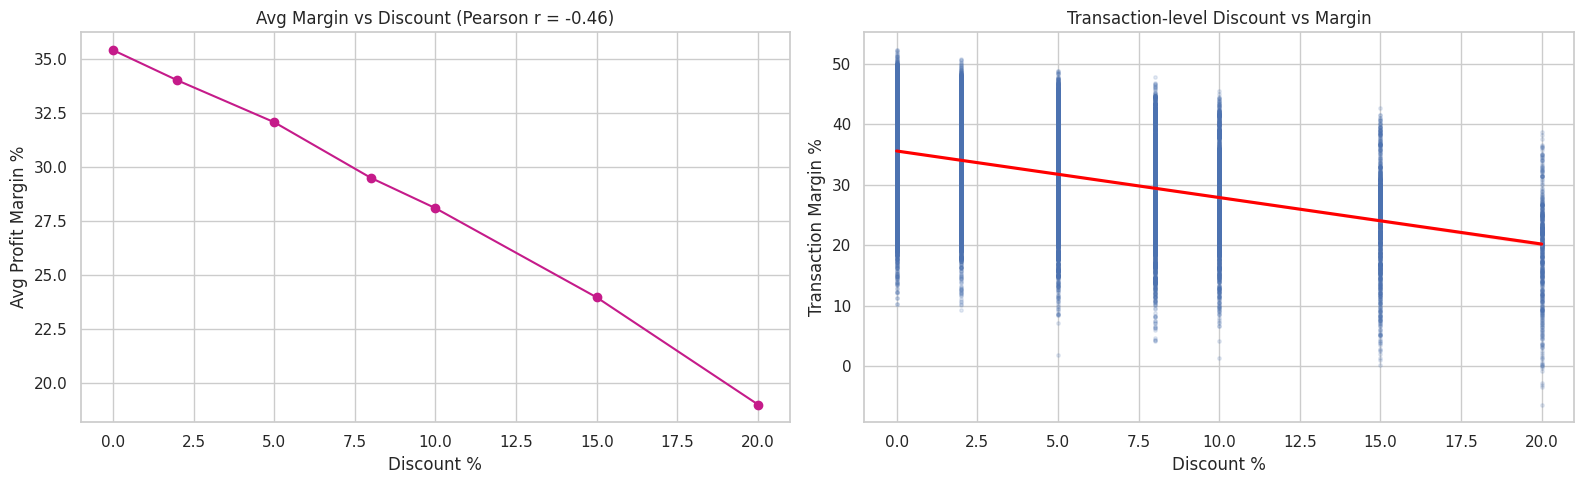

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))
ax[0].plot(band["Discount%"], band["AvgMargin%"], "-o", color="#c51b8a")
ax[0].set_xlabel("Discount %"); ax[0].set_ylabel("Avg Profit Margin %")
ax[0].set_title(f"Avg Margin vs Discount (Pearson r = {pear_r:.2f})")
sns.regplot(x=d.DiscountPct*100, y=d.Margin*100, scatter_kws={"s":6,"alpha":0.15},
            line_kws={"color":"red"}, ax=ax[1])
ax[1].set_xlabel("Discount %"); ax[1].set_ylabel("Transaction Margin %")
ax[1].set_title("Transaction-level Discount vs Margin")
plt.tight_layout(); plt.show()

Question 7

In [30]:
channel = (df.groupby("SalesChannel")
    .agg(Transactions=("TransactionID","count"), NetSales=("NetSales","sum"),
         GrossProfit=("GrossProfit","sum"))
    .reset_index())
channel["ProfitMargin%"] = channel.GrossProfit / channel.NetSales * 100
channel["AvgTxnValue"]   = channel.NetSales / channel.Transactions
channel["Sales%"]        = channel.NetSales / channel.NetSales.sum() * 100
channel.sort_values("NetSales", ascending=False).round(1)

,SalesChannel,Transactions,NetSales,GrossProfit,ProfitMargin%,AvgTxnValue,Sales%
2,Store,17551,"864,912,185.00","229,585,985.00",26.50,"49,279.90",70.10
1,Online,4960,"238,105,727.30","65,404,727.30",27.50,"48,005.20",19.30
0,Corporate,2524,"131,350,110.80","34,500,610.80",26.30,"52,040.50",10.60


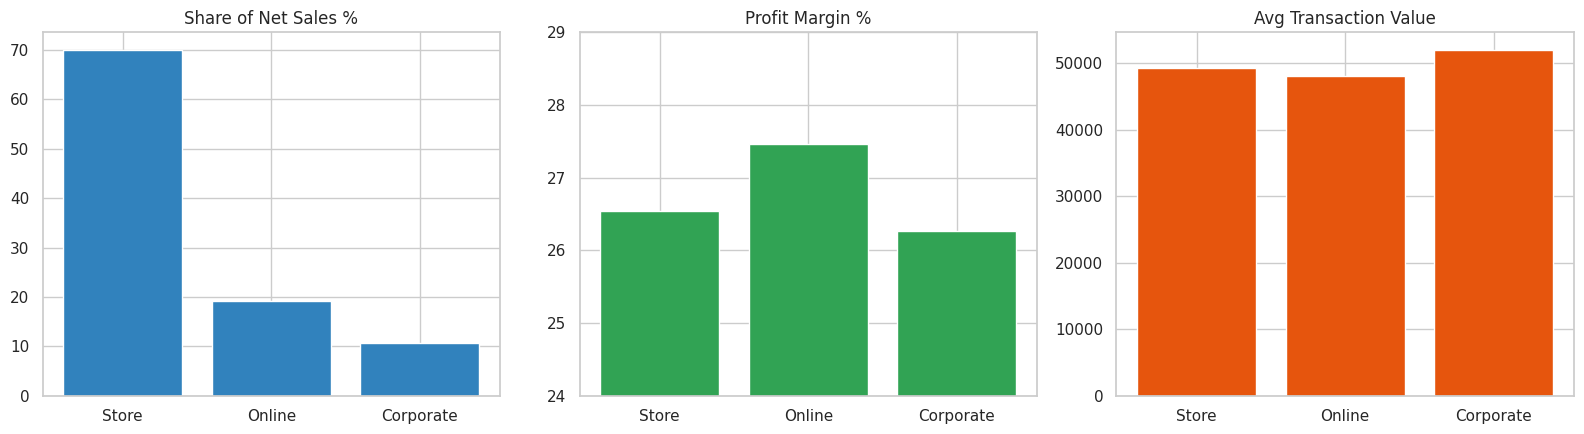

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
ch = channel.sort_values("NetSales", ascending=False)
ax[0].bar(ch.SalesChannel, ch["Sales%"], color="#3182bd"); ax[0].set_title("Share of Net Sales %")
ax[1].bar(ch.SalesChannel, ch["ProfitMargin%"], color="#31a354"); ax[1].set_title("Profit Margin %"); ax[1].set_ylim(24,29)
ax[2].bar(ch.SalesChannel, ch["AvgTxnValue"], color="#e6550d"); ax[2].set_title("Avg Transaction Value")
plt.tight_layout(); plt.show()

Question 8

In [32]:
ctab = pd.crosstab(df.CustomerType, df.SalesChannel)
print("Counts:"); print(ctab)
row_pct = pd.crosstab(df.CustomerType, df.SalesChannel, normalize="index")*100
print("\nRow % (channel mix within each customer type):"); print(row_pct.round(1))

chi2, p, dof, exp = stats.chi2_contingency(ctab)
print(f"\nChi-square = {chi2:.2f}, p = {p:.3f}, dof = {dof}")
print("=> " + ("association is statistically significant" if p < 0.05
      else "NO significant association (channels used the same way by all types)"))

Counts:
SalesChannel  Corporate  Online  Store
CustomerType                          
Individual         1813    3653  12708
Institution         151     246    876
SME                 560    1061   3967

Row % (channel mix within each customer type):
SalesChannel  Corporate  Online  Store
CustomerType                          
Individual        10.00   20.10  69.90
Institution       11.90   19.30  68.80
SME               10.00   19.00  71.00

Chi-square = 8.07, p = 0.089, dof = 4
=> NO significant association (channels used the same way by all types)


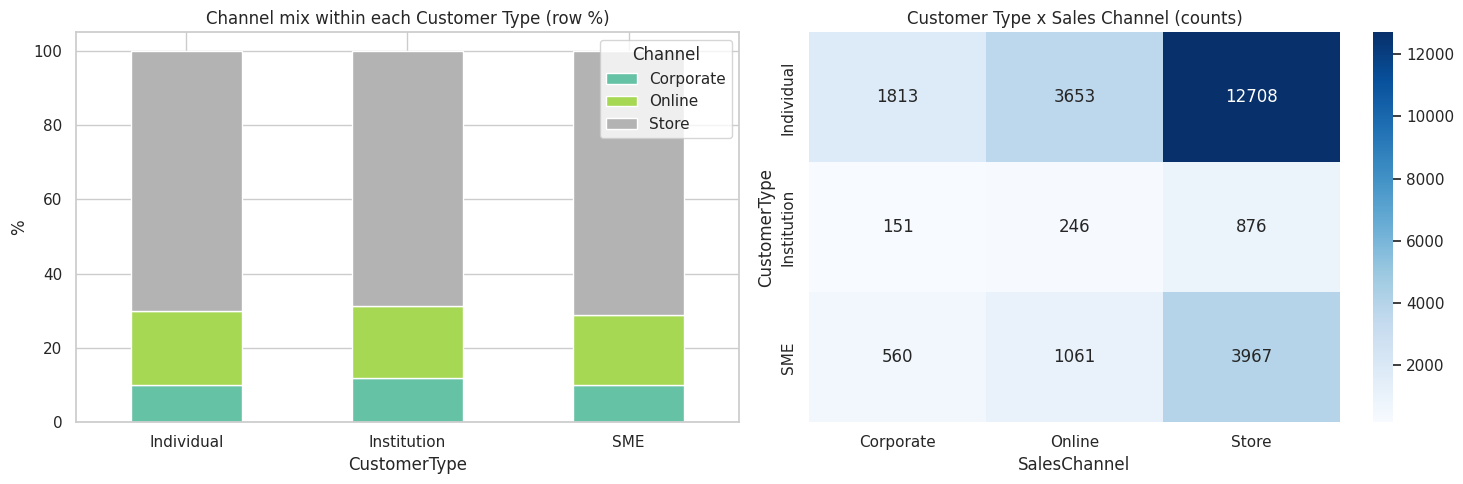

Who uses the Corporate channel (composition %):
CustomerType
Individual    71.80
SME           22.20
Institution    6.00
Name: proportion, dtype: float64


In [33]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
row_pct.plot(kind="bar", stacked=True, ax=ax[0], colormap="Set2")
ax[0].set_title("Channel mix within each Customer Type (row %)"); ax[0].set_ylabel("%")
ax[0].legend(title="Channel"); ax[0].tick_params(axis="x", rotation=0)
sns.heatmap(ctab, annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_title("Customer Type x Sales Channel (counts)")
plt.tight_layout(); plt.show()

print("Who uses the Corporate channel (composition %):")
print((df[df.SalesChannel=="Corporate"].CustomerType.value_counts(normalize=True)*100).round(1))

Question 9

In [34]:
total_sales, total_target = comp.NetSales.sum(), comp.Target.sum()
print(f"Full-year Net Sales : {total_sales:,.0f}")
print(f"Full-year Target    : {total_target:,.0f}")
print(f"Overall achievement : {total_sales/total_target*100:.1f}%")
print(f"Stores beating target: {(store_kpi['TargetAchievement%']>=100).sum()} of {len(store_kpi)}")
print(f"Champions+Potential revenue share: "
      f"{seg.loc[seg.Segment.isin(['Champions / Loyal','Potential Loyalist']),'Revenue%'].sum():.1f}%")
print(f"Electronics: sales {cat.loc[cat.Category=='Electronics','Sales%'].values[0]:.1f}% "
      f"vs profit {cat.loc[cat.Category=='Electronics','Profit%'].values[0]:.1f}%")

Full-year Net Sales : 1,234,368,023
Full-year Target    : 2,033,918,030
Overall achievement : 60.7%
Stores beating target: 1 of 8
Champions+Potential revenue share: 88.0%
Electronics: sales 52.6% vs profit 42.1%
